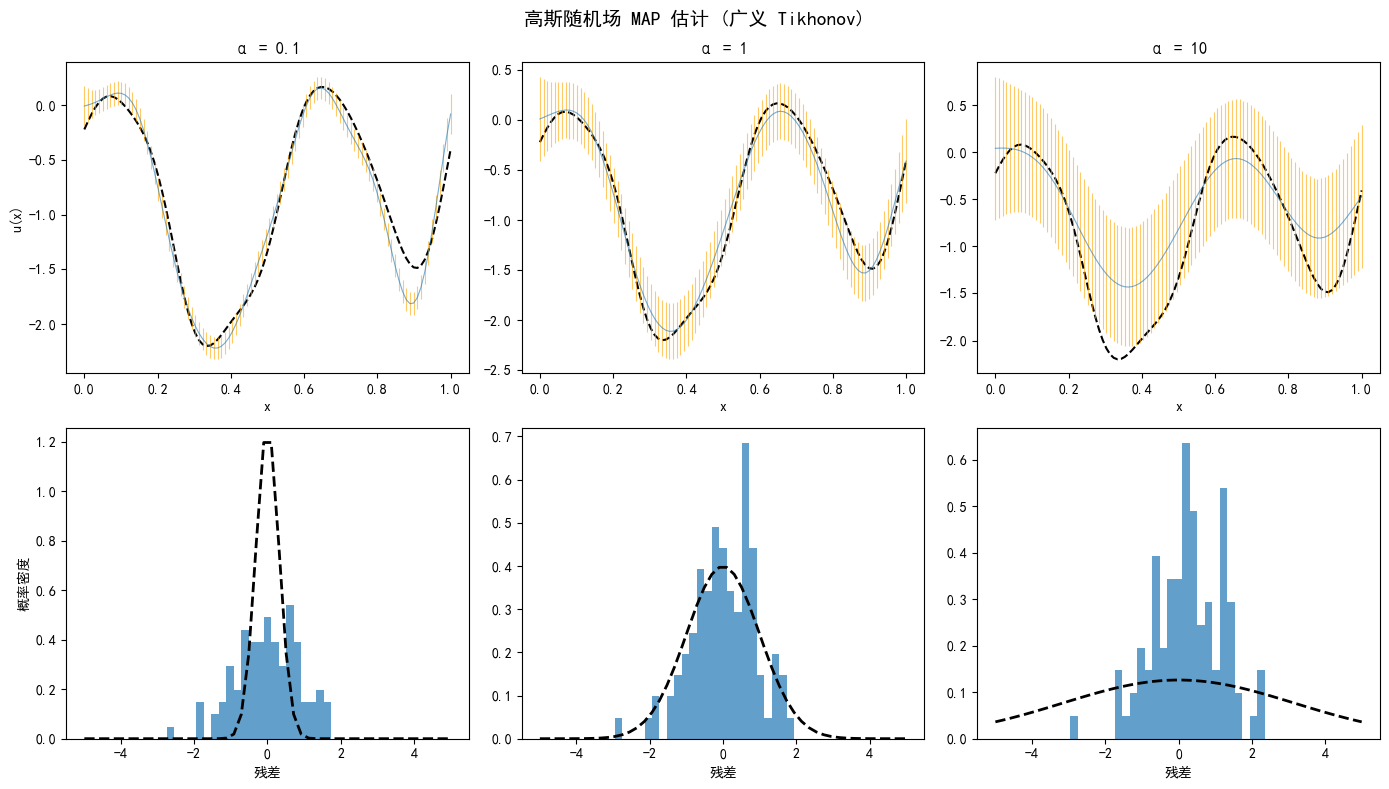

In [1]:
"""
实验2.3 高斯随机场采样与广义Tikhonov估计
对应章节：2.2 高斯先验 + 附录2A 共轭先验
知识点：高斯先验→Tikhonov正则化；相关长度L控制光滑度；广义Tikhonov；共轭先验闭式后验

素材来源：
  - IP22 (statistical_perspective.md): 高斯随机场采样 + MAP估计 + 后验协方差
  代码几乎逐行取自 IP22 的 code-cell
"""

import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
# 1. 彻底屏蔽 matplotlib 的字体警告日志
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. 忽略 Python 层面的相关 UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")

# 3. 强制使用 ASCII 减号（连字符）替代 Unicode 减号（U+2212），并设置中文字体
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

np.random.seed(3)

# ====== 来源: IP22 (statistical_perspective.md) ======

# 参数
n = 100
sigma = 1
L = 0.1
alpha = [0.1, 1, 10]

# 网格
x = np.linspace(0, 1, n)
x1, x2 = np.meshgrid(x, x)

# 先验协方差矩阵 (IP22: Sigma = exp(-|x1-x2|^2/(2*L^2)))
Sigma = np.exp(-np.abs(x1 - x2)**2 / (2 * L**2))

# 从高斯随机场采样 ground truth (IP22)
u = np.random.multivariate_normal(np.zeros(n), Sigma)

# 含噪数据 (IP22: f_delta = u + sigma*randn)
f_delta = u + sigma * np.random.randn(n)

# 不同 alpha 下的 MAP 估计 (IP22: u_map = solve(alpha*I + Sigma, Sigma @ f_delta))
u_map = [0, 0, 0]
Sigma_map = [0, 0, 0]

for k in range(3):
    # MAP-estimate
    u_map[k] = np.linalg.solve(alpha[k] * np.eye(n) + Sigma, Sigma @ f_delta)
    # 后验协方差 (共轭先验: 高斯-高斯闭式后验)
    Sigma_map[k] = alpha[k] * np.linalg.inv(Sigma + alpha[k] * np.eye(n)) @ Sigma

# ====== 可视化 (IP22 风格) ======
r = np.linspace(-5, 5, 50)
fig, ax = plt.subplots(2, 3, figsize=(14, 8))

for k in range(3):
    # 上行: MAP估计 + 误差棒
    ax[0, k].plot(x, u, 'k--', label='真实信号')
    ax[0, k].errorbar(x, u_map[k], yerr=np.sqrt(np.diag(Sigma_map[k])),
                      ecolor='orange', alpha=0.6, linewidth=0.8)
    ax[0, k].set_xlabel('x')
    ax[0, 0].set_ylabel('u(x)')
    ax[0, k].set_title(f'α = {alpha[k]}')

    # 下行: 残差直方图 vs 高斯预测 (IP22)
    ax[1, k].hist(u_map[k] - f_delta, bins=r, density=True, alpha=0.7)
    ax[1, k].plot(r, (1 / np.sqrt(2 * np.pi * alpha[k])) *
                  np.exp(-(0.5 / alpha[k]) * r**2), 'k--', linewidth=2)
    ax[1, k].set_xlabel('残差')
    ax[1, 0].set_ylabel('概率密度')

fig.suptitle('高斯随机场 MAP 估计 (广义 Tikhonov)', fontsize=14)
plt.tight_layout()
plt.savefig('2_3_result.png', dpi=150, bbox_inches='tight')
plt.show()
